In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import os
import math

In [47]:
DATA_PATH = '../results'
TIME=['second', 'hour', 'day', 'week', 'year']
TITLE_MAP = {
    'second': '1 Second',
    'hour': '1 Hour',
    'day': '1 Day',
    'week': '1 Week',
    'year': '1 Year',
}
OUTPUT_DIR = 'graph/device'


In [48]:
def find_acc(df):
    mask = ( (df['norm_accuracy'] >= 0.99) & (df['norm_accuracy'] < 1.00) )
    filtered_df = df[mask].copy()

    time_mapping = {
        1: 'second',
        3600: 'hour',
        3600*24: 'day',
        3600*24*7: 'week',
        3600*24*365: 'year'
    }
    filtered_df['time_str'] = filtered_df['t_inference'].map(time_mapping)
    return filtered_df


In [49]:
all_results = []
for time in TIME:
    csv_path = os.path.join(DATA_PATH, f'device_results_{time}.csv')
    df = pd.read_csv(csv_path)
    
    result_df = find_acc(df)
    all_results.append(result_df)

final_df = pd.concat(all_results, ignore_index=True)

best_df = (
    final_df
    .query("time_str in ['day','year']")
    .groupby(['device','time_str'])['norm_accuracy']
    .max()
    .unstack('time_str')
    .reset_index()
    .rename(columns={
        'day':'max_norm_accuracy_day',
        'year':'max_norm_accuracy_year'
    })
)
print(best_df)

time_str   device  max_norm_accuracy_day  max_norm_accuracy_year
0             cpl               0.999738                0.997966
1            homo               0.999691                0.998432
2         liner_1               0.999855                0.999972
3         liner_2               0.999989                0.999817
4             opt               0.999668                0.996159


# Plot Device Noise Tol

In [36]:
DATA_PATH = '../results'
TIME=['second', 'hour', 'day', 'week', 'year']
TITLE_MAP = {
    'second': '1 Second',
    'hour': '1 Hour',
    'day': '1 Day',
    'week': '1 Week',
    'year': '1 Year',
}
OUTPUT_DIR = 'graph/device'


In [37]:
def find_noise_threshold(df):

    mask = df['norm_accuracy'] >= 0.995
    filtered_df = df[mask]

    result_df = (
        filtered_df
        .groupby(['device', 't_inference'])['noise_scale']
        .max()
        .reset_index()
        .rename(columns={'noise_scale': 'noise_tolerance'})
    )
    time_mapping = {
        1: 'second',
        3600: 'hour',
        3600 * 24: 'day',
        3600 * 24 * 7: 'week',
        3600 * 24 * 365: 'year'
    }

    result_df['time_str'] = result_df['t_inference'].map(time_mapping)
    return result_df

In [38]:

all_results = []
for time in TIME:
    csv_path = os.path.join(DATA_PATH, f'device_results_{time}.csv')
    df = pd.read_csv(csv_path)
    
    result_df = find_noise_threshold(df)
    all_results.append(result_df)

final_df = pd.concat(all_results, ignore_index=True)

'''mask_day = (final_df['device'] == 'opt') & (final_df['time_str'] == 'day')
mask_hour = (final_df['device'] == 'opt') & (final_df['time_str'] == 'hour')

val_day = final_df.loc[mask_day, 'noise_tolerance'].values[0]
val_hour = final_df.loc[mask_hour, 'noise_tolerance'].values[0]

final_df.loc[mask_day, 'noise_tolerance'] = val_hour
final_df.loc[mask_hour, 'noise_tolerance'] = val_day
'''

     device  t_inference  noise_tolerance time_str
0       cpl            1             1.80   second
1      homo            1             1.60   second
2   liner_1            1             2.00   second
3   liner_2            1             2.00   second
4       opt            1             2.25   second
5       cpl         3600             1.80     hour
6      homo         3600             1.60     hour
7   liner_1         3600             1.80     hour
8   liner_2         3600             2.00     hour
9       opt         3600             1.40     hour
10      cpl        86400             1.80      day
11     homo        86400             1.20      day
12  liner_1        86400             1.80      day
13  liner_2        86400             1.80      day
14      opt        86400             1.80      day
15      cpl       604800             1.60     week
16     homo       604800             1.20     week
17  liner_1       604800             1.80     week
18  liner_2       604800       

"mask_day = (final_df['device'] == 'opt') & (final_df['time_str'] == 'day')\nmask_hour = (final_df['device'] == 'opt') & (final_df['time_str'] == 'hour')\n\nval_day = final_df.loc[mask_day, 'noise_tolerance'].values[0]\nval_hour = final_df.loc[mask_hour, 'noise_tolerance'].values[0]\n\nfinal_df.loc[mask_day, 'noise_tolerance'] = val_hour\nfinal_df.loc[mask_hour, 'noise_tolerance'] = val_day\n"

/tmp/ipykernel_16723/261155452.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = heatmap_data.applymap(lambda v: f"$\\sim${v:.2f}")


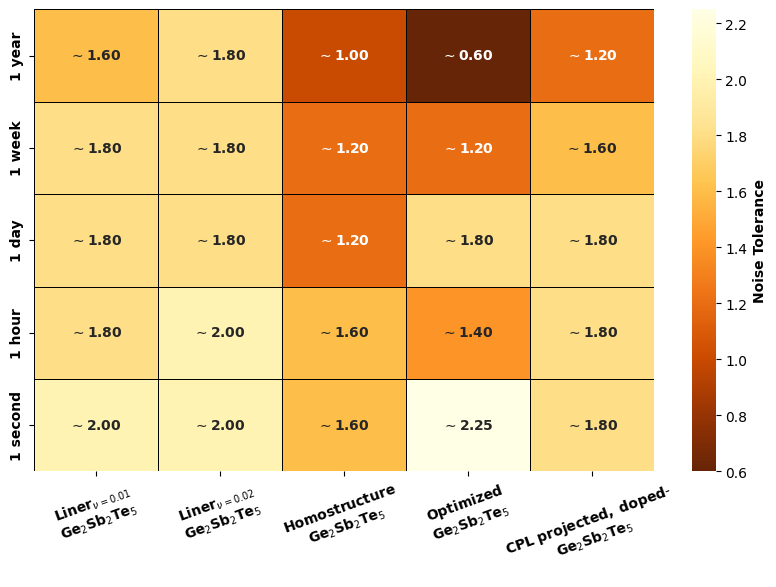

In [39]:

device_label_map = {
    'liner_1': "$\\mathbf{Liner}_{\\nu=0.01}$\n$\\mathbf{Ge}_{2}\\mathbf{Sb}_{2}\\mathbf{Te}_{5}$",
    'liner_2': "$\\mathbf{Liner}_{\\nu=0.02}$\n$\\mathbf{Ge}_{2}\\mathbf{Sb}_{2}\\mathbf{Te}_{5}$",
    'homo':     "$\\mathbf{Homostructure}$\n$\\mathbf{Ge}_{2}\\mathbf{Sb}_{2}\\mathbf{Te}_{5}$",
    'opt':      "$\\mathbf{Optimized}$\n$\\mathbf{Ge}_{2}\\mathbf{Sb}_{2}\\mathbf{Te}_{5}$",
    'cpl':      "$\\mathbf{CPL\\ projected,\\ doped\\text{-}}$\n$\\mathbf{Ge}_{2}\\mathbf{Sb}_{2}\\mathbf{Te}_{5}$"
}



final_df['device_pretty'] = final_df['device'].map(device_label_map)
final_df['time_label'] = final_df['time_str'].apply(lambda s: f'1 {s}')
heatmap_data = final_df.pivot(index='time_label', columns='device_pretty', values='noise_tolerance')
time_order = ['1 second', '1 hour', '1 day', '1 week', '1 year']
heatmap_data = heatmap_data.reindex(time_order)
device_order = [device_label_map[d] for d in ['liner_1', 'liner_2', 'homo', 'opt', 'cpl']]
heatmap_data = heatmap_data[device_order]
annot_data = heatmap_data.applymap(lambda v: f"$\\sim${v:.2f}")

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    data=heatmap_data,        
    annot=annot_data,        
    fmt="",                  
    cmap="YlOrBr_r",
    cbar_kws={'label': 'Noise Tolerance'},
    linewidths=0.6,
    linecolor='black'
)
ax.invert_yaxis()
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, weight='bold')
ax.collections[0].colorbar.ax.yaxis.label.set_size(10)
ax.collections[0].colorbar.ax.yaxis.label.set_weight('bold')
for text in ax.texts:
        text.set_fontsize(10)
        text.set_weight('bold')
plt.xticks(rotation=20)
os.makedirs(OUTPUT_DIR, exist_ok=True) 
#plt.savefig(f'{OUTPUT_DIR}/device_noise_tolerance.png')
plt.show()